In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import os
import kagglehub

# 1. Dataset Paths

In [ ]:
print("Downloading FER2013 dataset from Kaggle...")
path = kagglehub.dataset_download("msambare/fer2013")
print("Path to dataset files:", path)

train_path = os.path.join(path, "train")
test_path = os.path.join(path, "test")

print("Training Data Path:", train_path)
print("Testing Data Path:", test_path)



Path to dataset files: C:\Users\jm270\.cache\kagglehub\datasets\msambare\fer2013\versions\1
Training Data Path: C:\Users\jm270\.cache\kagglehub\datasets\msambare\fer2013\versions\1\train
Testing Data Path: C:\Users\jm270\.cache\kagglehub\datasets\msambare\fer2013\versions\1\test


#  2. Data Preprocessing (Image Generators)

In [12]:
img_width, img_height = 48, 48
batch_size = 64

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

print("\nLoading Training Data...")

try:
    train_generator = train_datagen.flow_from_directory(
        train_path,
        target_size=(img_width, img_height),
        batch_size=batch_size,
        color_mode="grayscale",
        class_mode='categorical'
    )
except Exception as e:
    print("Could not load training data. Check path.", e)
    train_generator = None

print("\nLoading Testing/Validation Data...")
try:
    test_generator = test_datagen.flow_from_directory(
        test_path,
        target_size=(img_width, img_height),
        batch_size=batch_size,
        color_mode="grayscale",
        class_mode='categorical'
    )
except Exception as e:
    print("Could not load testing data. Check path.", e)
    test_generator = None



Loading Training Data...
Found 28709 images belonging to 7 classes.

Loading Testing/Validation Data...
Found 7178 images belonging to 7 classes.


# 3. Model Building (CNN)

In [13]:
print("\nBuilding the CNN Model...")

model = Sequential()

# First Convolutional Block
# Conv2D + ReLU + MaxPooling
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(img_width, img_height, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Second Convolutional Block
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Third Convolutional Block
model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Flattening to convert 2D features to 1D vector
model.add(Flatten())

# Fully Connected (Dense) Layer
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.5))

# Output Softmax Layer (7 emotions)
num_classes = 7
model.add(Dense(num_classes, activation='softmax'))


Building the CNN Model...


c:\Users\jm270\miniconda3\envs\apexx\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# 4. Compile the Model

In [14]:
model.compile(
    loss='categorical_crossentropy',  
    optimizer='adam',                 
    metrics=['accuracy']              
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         7,175 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,198,023 (8.38 MB)

 Trainable params: 2,198,023 (8.38 MB)

 Non-trainable params: 0 (0.00 B)

# 5. Training the Model

In [15]:
print("\nStarting Training...")
epochs = 50

if train_generator and test_generator:
    history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.n // train_generator.batch_size,
        epochs=epochs,
        validation_data=test_generator,
        validation_steps=test_generator.n // test_generator.batch_size
    )


Starting Training...
Epoch 1/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 421s 937ms/step - accuracy: 0.3150 - loss: 1.7013 - val_accuracy: 0.4132 - val_loss: 1.5356
Epoch 2/50
  1/448 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.4375 - loss: 1.5045

c:\Users\jm270\miniconda3\envs\apexx\lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4375 - loss: 1.5045 - val_accuracy: 0.4121 - val_loss: 1.5366
Epoch 3/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.4269 - loss: 1.4849 - val_accuracy: 0.4759 - val_loss: 1.3634
Epoch 4/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3750 - loss: 1.4513 - val_accuracy: 0.4756 - val_loss: 1.3645
Epoch 5/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.4787 - loss: 1.3679 - val_accuracy: 0.5127 - val_loss: 1.2882
Epoch 6/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4688 - loss: 1.3059 - val_accuracy: 0.5106 - val_loss: 1.2862
Epoch 7/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.5055 - loss: 1.2991 - val_accuracy: 0.5264 - val_loss: 1.2348
Epoch 8/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5156 - loss: 1.2334 - val_accuracy: 0.5290 - val_loss: 1.2335
Epoch 9/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.5271 - loss: 1.2425 - val_accuracy: 0.541

# 6. Save the Model

In [17]:
model.save('emotion_model.h5')
print("\nModel saved as 'emotion_model.h5'")


Model saved as 'emotion_model.h5'


# 7. Evaluation & Visualization

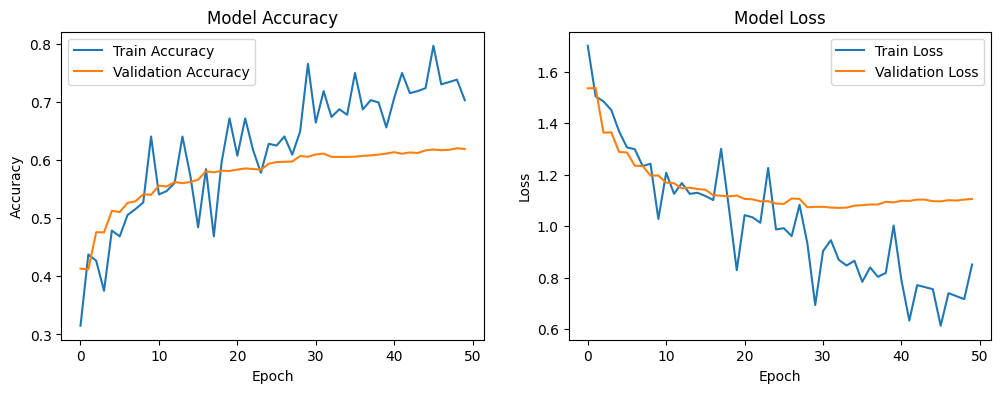

In [19]:
 plt.figure(figsize=(12, 4))
    
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')``
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

NameError: name 'history' is not defined

<Figure size 800x600 with 0 Axes>

# OPNECV for real-time emotion detection

In [1]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
import os

# --- 1. Load the pre-trained model ---
model_path = 'emotion_model.h5'

if not os.path.exists(model_path):
    print(f"Error: Could not find '{model_path}'.")
    print("Please run train_model.py first to train and save the model.")
    exit(1)

print("Loading the trained CNN model...")
model = load_model(model_path)

# --- 2. Load the Haar Cascade Classifier for Face Detection ---
# OpenCV provides a pre-trained face detector XML file.
cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_classifier = cv2.CascadeClassifier(cascade_path)

if face_classifier.empty():
    print(f"Error: Could not load cascade from {cascade_path}")
    exit(1)

# Emotion Labels corresponding to the FER2013 dataset classes
# Note: Ensure these match the dictionary output of train_generator.class_indices
# Commonly it is ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']
# You can check this by printing train_generator.class_indices during training.
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']

# --- 3. Start Video Capture ---
# '0' usually refers to your default laptop webcam
cap = cv2.VideoCapture(0)

print("\nStarting Webcam... Press 'q' to quit.")

while True:
    # Capture frame-by-frame
    ret, frame = cap.read()
    if not ret:
        print("Failed to grab frame. Make sure your webcam is connected.")
        break
    
    # Convert image to grayscale for face detection and emotion prediction
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    # Detect faces in the current frame
    faces = face_classifier.detectMultiScale(
        gray,
        scaleFactor=1.3,
        minNeighbors=5,
        minSize=(30, 30)
    )
    
    # Loop over all detected faces
    for (x, y, w, h) in faces:
        # Draw a rectangle around the face
        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)
        
        # Extract the Region of Interest (ROI) containing just the face
        roi_gray = gray[y:y+h, x:x+w]
        
        # Resize the face image to 48x48 (what our CNN expects)
        roi_gray = cv2.resize(roi_gray, (48, 48), interpolation=cv2.INTER_AREA)
        
        # Normalize the pixel values (0-1)
        roi = roi_gray / 255.0
        
        # Reshape to (1, 48, 48, 1) because Keras expects batches
        roi = np.reshape(roi, (1, 48, 48, 1))
        
        # Predict the emotion
        prediction = model.predict(roi, verbose=0)
        
        # Get the index of the highest probability prediction
        max_index = np.argmax(prediction[0])
        
        # Get the corresponding emotion label
        label = emotion_labels[max_index]
        label_position = (x, y - 10)
        
        # Overlay the emotion text on the frame
        cv2.putText(frame, label, label_position, cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    
    # Display the resulting frame
    cv2.imshow('Emotion Detector', frame)
    
    # Wait for 'q' key to stop the program
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# --- 4. Cleanup ---
cap.release()
cv2.destroyAllWindows()


Loading the trained CNN model...



Starting Webcam... Press 'q' to quit.
